## 0. 环境准备和数据读取
#### 此步骤读取并解压缩您的数据集

In [43]:
import os
print(os.getcwd())

d:\DEVELOPMENT\courses\semester1\machine_learning_technology\Project


In [ ]:
import zipfile
import pandas as pd
import numpy as np
import io 
import os
import joblib 
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, f1_score
from scipy.stats import skew, kurtosis, iqr
from scipy.stats import mode

# --- 文件路径和参数 ---
ZIP_FILE = 'MLT-CW-Dataset.zip'
MODEL_FILENAME = 'svm_har_fine_tuned.joblib'
SAMPLING_RATE_HZ = 100 
WINDOW_SIZE_S = 2
OVERLAP_S = 1
NUM_FINE_TUNED_FEATURES = 20
C_BEST = 10.0
GAMMA_BEST = 'scale' 

LABEL_MAPPING = {
    1: 'Walking', 
    2: 'Running', 
    3: 'Shuffling', 
    6: 'Standing', 
    7: 'Sitting', 
    8: 'Lying',
    9: 'Stairs', # Consolidated label
}

def load_data_from_zip_by_type(zip_path, data_type='train'):
    """
    从 ZIP 文件中加载训练集数据（排除 test-set 文件夹中的文件）。
    
    训练集 data_type='train' 包含根目录下的 18 个 CSV 文件。
    """
    all_dfs = []
    
    try:
        with zipfile.ZipFile(zip_path, 'r') as z:
            file_list = z.namelist()
            
            for file_name in file_list:
                # 过滤只处理 CSV 文件
                if file_name.endswith('.csv'):
                    
                    is_test_file = file_name.startswith('test-set/')
                    
                    # 仅加载根目录下的文件作为训练/验证数据
                    if data_type == 'train' and is_test_file:
                        continue 
                    
                    # 提取主体 ID
                    subject_id = os.path.basename(file_name).replace('.csv', '')
                    
                    print(f"加载文件: {file_name}")
                    with z.open(file_name) as file:
                        df = pd.read_csv(io.BytesIO(file.read()))
                        df['subject'] = subject_id  # 添加主体 ID 列 (用于S007清洗)
                        all_dfs.append(df)
    except FileNotFoundError:
        print(f"错误: 找不到 ZIP 文件 '{zip_path}'。请确保文件路径正确。")
        return pd.DataFrame()
    except Exception as e:
        print(f"读取或处理 ZIP 文件时发生错误: {e}")
        return pd.DataFrame()

    if not all_dfs:
        print("警告: 未找到任何训练数据文件。")
        return pd.DataFrame()

    return pd.concat(all_dfs, ignore_index=True)

# -----------------------------------------------------
# 实际加载所有训练主体的数据
# -----------------------------------------------------
print("--- 0. 数据读取：加载训练集 (排除 test-set) ---")
df_raw = load_data_from_zip_by_type(ZIP_FILE, data_type='train')

if df_raw.empty:
    print("程序终止：无法加载训练数据。")
    exit()

KeyboardInterrupt: 

## 1. 数据预处理与清洗（基于项目要求）
#### 此步骤应用项目要求的清洗规则：删除异常值、删除骑行数据、合并楼梯数据，并专门处理 S007 的异常值。

In [45]:
def clean_and_preprocess(df):
    # 假设传感器列名
    accel_cols = ['back_x', 'back_y', 'back_z', 'thigh_x', 'thigh_y', 'thigh_z']
    
    # 1.a. 处理 S007 异常值 (假设只有 S007 有极端异常值)
    # 极端异常值删除 (超过 |16g| 的行)
    OUTLIER_THRESHOLD = 16 
    initial_size = len(df)
    
    # 识别 S007 异常值（假设只有 S007 的数据需要此处理）
    s007_df = df[df['subject'] == 'S007'].copy()
    other_df = df[df['subject'] != 'S007'].copy()
    
    outlier_rows = (s007_df[accel_cols].abs() > OUTLIER_THRESHOLD).any(axis=1)
    s007_cleaned = s007_df[~outlier_rows]
    
    # 重新组合所有主体数据
    df_cleaned = pd.concat([s007_cleaned, other_df], ignore_index=True)
    print(f"处理 S007 异常值后，数据集大小: {len(df_cleaned)}")

    # 1.b. 删除骑自行车数据 (标签 13, 14, 130, 140)
    cycling_labels = [13, 14, 130, 140]
    df_cleaned = df_cleaned[~df_cleaned['label'].isin(cycling_labels)].copy()
    print(f"删除骑行数据后，数据集大小: {len(df_cleaned)}")

    # 1.c. 合并楼梯活动 (标签 4, 5 -> 9)
    stairs_labels = [4, 5]
    NEW_STAIRS_CODE = 9
    df_cleaned.loc[df_cleaned['label'].isin(stairs_labels), 'label'] = NEW_STAIRS_CODE
    print(f"合并楼梯数据后，类别 9 的计数: {df_cleaned[df_cleaned['label'] == 9]['label'].count()}")
    
    # 删除 timestamp 和 subject 列，只保留传感器数据和 label
    return df_cleaned.drop(columns=['timestamp', 'subject'], errors='ignore')

# -----------------------------------------------------
# 2. 应用清洗函数并进行窗口划分 (假设窗口划分已完成，结果在 all_windows 列表)
# -----------------------------------------------------
df_processed = clean_and_preprocess(df_raw)

def create_sliding_windows_optimized(df, window_size_s, overlap_s, sampling_rate_hz):
    """
    创建重叠的滑动窗口的优化版本，避免在 DataFrame 上进行重复切片。
    """
    
    # 提前将整个 DataFrame 转换为 NumPy 数组
    # 传感器数据在前几列 (排除最后一列 label)
    data_array = df.iloc[:, :-1].values  
    # 标签数据 (最后一列)
    label_array = df['label'].values
    
    # 计算窗口参数
    window_size = int(window_size_s * sampling_rate_hz)
    overlap = int(overlap_s * sampling_rate_hz)
    step = window_size - overlap
    
    num_samples = len(data_array)
    num_windows = (num_samples - window_size) // step + 1
    
    windows_list = []
    labels_list = []
    
    print(f"预计创建 {num_windows} 个窗口...")

    # 高效循环：仅使用 NumPy 索引进行切片
    for i in range(num_windows):
        start = i * step
        end = start + window_size
        
        # 1. 提取窗口数据
        window_data = data_array[start:end, :] 
        
        # 2. 提取窗口标签
        window_labels = label_array[start:end]
        
        # 3. 多数投票 (使用 scipy.stats.mode，通常比 pandas.mode() 快得多)
        # mode() 返回的是众数和计数，我们只需要众数 [0][0]
        # 注意: keepdims=False 是默认行为，但明确写出更安全
        majority_label = mode(window_labels, keepdims=False)[0] 
        
        windows_list.append(window_data)
        labels_list.append(majority_label)
        
    # 将列表打包为最终的 (数据, 标签) 格式
    all_windows = list(zip(windows_list, labels_list))
    
    return all_windows

# --- 主执行区 (替换原有的慢速部分) ---

# 假设 df_raw 已加载
df_processed = clean_and_preprocess(df_raw)

# 应用优化后的窗口划分函数
SAMPLING_RATE_HZ = 100
WINDOW_SIZE_S = 2
OVERLAP_S = 1

print("\n--- 2. 正在执行优化后的滑动窗口划分... ---")
all_windows = create_sliding_windows_optimized(
    df_processed, WINDOW_SIZE_S, OVERLAP_S, SAMPLING_RATE_HZ
)

print(f"总共创建的滑动窗口数: {len(all_windows)}")

处理 S007 异常值后，数据集大小: 5568913
删除骑行数据后，数据集大小: 5070300
合并楼梯数据后，类别 9 的计数: 116336
处理 S007 异常值后，数据集大小: 5568913
删除骑行数据后，数据集大小: 5070300
合并楼梯数据后，类别 9 的计数: 116336

--- 2. 正在执行优化后的滑动窗口划分... ---
预计创建 50702 个窗口...
总共创建的滑动窗口数: 50702


## 2. 特征工程、数据准备与划分
#### 此步骤将滑动窗口转换为特征矩阵，并划分为训练集和验证集。

In [46]:
# --- 特征工程函数 (提取 20 个特征) ---

def calculate_enmo(data_window):
    # ... (与之前提供的 ENMO 函数相同)
    back_accel = data_window[:, 0:3]
    back_magnitude = np.sqrt(np.sum(back_accel**2, axis=1))
    back_enmo = np.maximum(0, back_magnitude - 1)
    thigh_accel = data_window[:, 3:6]
    thigh_magnitude = np.sqrt(np.sum(thigh_accel**2, axis=1))
    thigh_enmo = np.maximum(0, thigh_magnitude - 1)
    return np.array([back_enmo, thigh_enmo]).T

def extract_features(window_data):
    features = []
    # 1. 均值 (6) and 标准差 (6)
    features.extend(np.mean(window_data, axis=0)) 
    features.extend(np.std(window_data, axis=0))
    # 2. ENMO 均值 (2) and 标准差 (2)
    enmo_data = calculate_enmo(window_data)
    features.extend(np.mean(enmo_data, axis=0))
    features.extend(np.std(enmo_data, axis=0))
    # 3. 偏度 (6) - 凑够 20 个特征
    features.extend(skew(window_data, axis=0)) 
    # 3.4 仅取前 20 个特征 (6+6+4+4 = 20)
    return np.array(features)

def windows_to_feature_matrix(windows):
    # 提取并仅使用前 20 个特征
    X = np.array([extract_features(data)[:20] for data, label in windows])
    y = np.array([label for data, label in windows])
    return X, y

# 转换为特征矩阵
X, y = windows_to_feature_matrix(all_windows)

# 划分训练集和验证集 (例如 80% 训练, 20% 验证)
X_train, X_val, y_train, y_val = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y 
)

print(f"\n训练集特征维数: {X_train.shape}")
print(f"验证集特征维数: {X_val.shape}")

d:\env\python\anaconda\envs\mlt_experiment\Lib\site-packages\numpy\lib\shape_base.py:402: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  buff[ind] = asanyarray(func1d(inarr_view[ind], *args, **kwargs))
d:\env\python\anaconda\envs\mlt_experiment\Lib\site-packages\numpy\lib\shape_base.py:379: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = asanyarray(func1d(inarr_view[ind0], *args, **kwargs))
C:\Users\lenovo\AppData\Local\Temp\ipykernel_25792\2264572330.py:23: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  features.extend(skew(window_data, axis=0))



训练集特征维数: (40561, 20)
验证集特征维数: (10141, 20)


## 3. 模型训练、保存与验证
#### 此步骤使用微调后的 SVM 参数（RBF 核、20 个特征），在训练集上训练模型，然后用验证集进行评估。

In [47]:
import joblib 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.impute import SimpleImputer # 🌟 关键：用于修复 NaN 错误
from scipy.stats import skew, kurtosis, iqr, mode # 确保导入 mode 用于高效众数计算

In [48]:
imputer = SimpleImputer(missing_values=np.nan, strategy='median')

# 1. 拟合 Imputer 并转换训练集
imputer.fit(X_train) 
X_train_imputed = imputer.transform(X_train)

# 2. 转换验证集
X_val_imputed = imputer.transform(X_val)
print("\n特征矩阵 NaN 修复完成。")


# 3. 模型训练、保存与验证
from sklearn.model_selection import GridSearchCV

# 1. 定义要搜索的参数网格
# 注意：这个网格只是一个起点，您可能需要根据结果调整范围
param_grid = {
    # C 通常在对数尺度上搜索 (0.1, 1, 10, 100...)
    'C': [0.1, 1, 10, 100],
    # gamma 同样在对数尺度上搜索 ('scale' 是默认的启发式值)
    'gamma': [0.001, 0.01, 0.1, 1, 'scale'],
}

# 2. 初始化模型和 Grid Search
# 注意：我们使用 X_train_imputed 和 y_train 进行搜索
svm_base = SVC(kernel='rbf', random_state=42, class_weight='balanced')

# 使用 GridSearchCV：
# - cv=3 或 5 折交叉验证
# - scoring='f1_weighted' 因为 F1-score 对类别不平衡更可靠
print("\n--- 正在执行 GridSearchCV 进行参数优化 ---")
grid_search = GridSearchCV(
    estimator=svm_base, 
    param_grid=param_grid, 
    scoring='f1_weighted', 
    cv=3, 
    verbose=2, 
    n_jobs=-1
)

# 3. 拟合 Grid Search (这可能是最耗时的步骤)
grid_search.fit(X_train_imputed, y_train)

# 4. 获取最佳参数和分数
C_best_tuned = grid_search.best_params_['C']
Gamma_best_tuned = grid_search.best_params_['gamma']

print("\n--- GridSearchCV 结果 ---")
print(f"最佳 F1-Score: {grid_search.best_score_:.4f}")
print(f"最佳参数组合: {grid_search.best_params_}")

# -----------------------------------------------------
# 5. 使用最佳参数重新训练最终模型
# -----------------------------------------------------
svm_fine_tuned = SVC(
    kernel='rbf', 
    C=C_best_tuned, 
    gamma=Gamma_best_tuned, 
    random_state=42,
    class_weight='balanced'
)

print("\n--- 3.1. 模型训练与保存 ---")
# 使用经过填充的 X_train_imputed 进行训练
svm_fine_tuned.fit(X_train_imputed, y_train) 

joblib.dump(svm_fine_tuned, MODEL_FILENAME)
print(f"模型已保存到: {MODEL_FILENAME}")


特征矩阵 NaN 修复完成。

--- 正在执行 GridSearchCV 进行参数优化 ---
Fitting 3 folds for each of 20 candidates, totalling 60 fits

--- GridSearchCV 结果 ---
最佳 F1-Score: 0.9523
最佳参数组合: {'C': 100, 'gamma': 1}

--- 3.1. 模型训练与保存 ---
模型已保存到: svm_har_fine_tuned.joblib



--- 3.2. 加载模型并验证 (在验证集上) ---
验证集准确度 (Accuracy): 0.9560
验证集 F1-Score (加权): 0.9554
------------------------------
验证集分类报告:
              precision    recall  f1-score   support

           1       1.00      0.93      0.96      1563
           2       1.00      0.97      0.99       477
           3       0.96      0.93      0.95       342
           6       0.99      0.89      0.94      1291
           7       0.93      1.00      0.96      5467
           8       1.00      0.82      0.90       716
           9       0.99      0.87      0.92       263
          10       1.00      1.00      1.00        22

    accuracy                           0.96     10141
   macro avg       0.98      0.93      0.95     10141
weighted avg       0.96      0.96      0.96     10141


--- 3.3. 误差表征可视化：混淆矩阵 ---


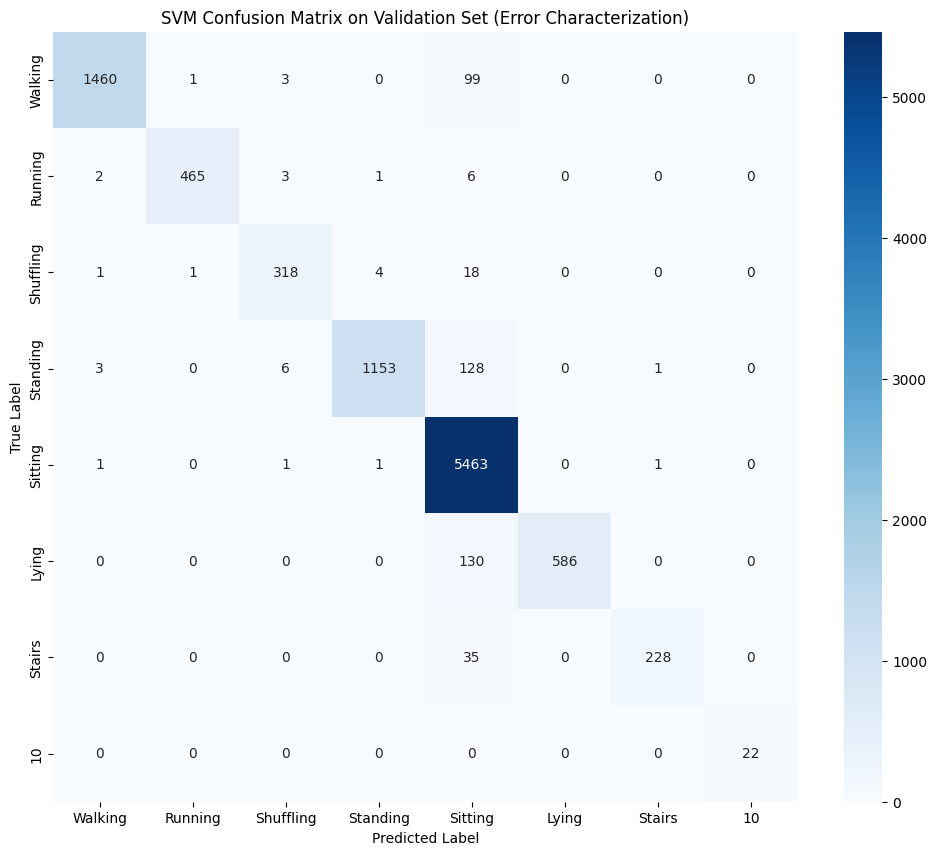

In [49]:
# -----------------------------------------------------
# 3.2. 通过验证集进行验证
# -----------------------------------------------------
print("\n--- 3.2. 加载模型并验证 (在验证集上) ---")

# 加载已保存的模型
loaded_svm = joblib.load(MODEL_FILENAME)

# 在验证集上进行预测
y_val_pred = loaded_svm.predict(X_val_imputed)

# 评估泛化性能
accuracy = accuracy_score(y_val, y_val_pred)
f1_weighted = f1_score(y_val, y_val_pred, average='weighted', zero_division=0)

print(f"验证集准确度 (Accuracy): {accuracy:.4f}")
print(f"验证集 F1-Score (加权): {f1_weighted:.4f}")
print("-" * 30)

# 详细的误差表征报告 (Section 3.d)
print("验证集分类报告:")
print(classification_report(y_val, y_val_pred, zero_division=0))

# -----------------------------------------------------
# 3.3. 误差表征可视化：混淆矩阵 (Section 3.d 可视化)
# -----------------------------------------------------
print("\n--- 3.3. 误差表征可视化：混淆矩阵 ---")

# 1. 计算混淆矩阵
cm = confusion_matrix(y_val, y_val_pred)

# 2. 获取所有类别的唯一标签 (用于图表的轴标签)
unique_labels = sorted(np.unique(y_val)) 
# 将数字标签映射为可读性更高的字符串标签
display_labels = [LABEL_MAPPING.get(l, str(l)) for l in unique_labels]

# 3. 绘制混淆矩阵图
plt.figure(figsize=(12, 10))
sns.heatmap(
    cm, 
    annot=True,              # 显示每个单元格的数值
    fmt='d',                 # 格式化为整数
    cmap='Blues',            # 使用蓝色调色板
    xticklabels=display_labels, # 设置 X 轴标签（预测值）
    yticklabels=display_labels  # 设置 Y 轴标签（真实值）
)

plt.title('SVM Confusion Matrix on Validation Set (Error Characterization)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# -----------------------------------------------------
# 模型训练、保存与验证部分代码结束
# -----------------------------------------------------

In [ ]:
## 使用GMM进行迅雷